# Kalp Hastalığı Tahmini — Gradient Boosting Classifier

Bu notebook, UCI Heart Disease (Cleveland) veri seti üzerinde bir
`GradientBoostingClassifier` ile ikili sınıflandırma yapar: bir hastada
kalp hastalığı olup olmadığını (`target`) tahmin eder.

**Akış:** veri yükleme → keşifçi veri analizi → eğitim/test ayrımı →
çoklu doğrusallık kontrolü → temel (baseline) model → hiperparametre
optimizasyonu → final değerlendirme → özellik önemleri → model kaydı.

**Veri kaynakları**
- Kaggle: https://www.kaggle.com/datasets/dharanireddy/heart-disease/data
- UCI ML Repository: https://archive.ics.uci.edu/dataset/45/heart+disease

In [1]:
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report , confusion_matrix ,ConfusionMatrixDisplay ,RocCurveDisplay , roc_auc_score

import joblib
%matplotlib inline
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

MODELS_DIR = Path("modeller")
MODELS_DIR.mkdir(parents=True , exist_ok = True)

MODEL_PATH = MODELS_DIR /f"gradient_boosting_heart_.joblib"

## 1. Veri yükleme

In [2]:
df = pd.read_csv("heart.csv")

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 2. Keşifçi veri analizi (EDA)

Veri tiplerini, eksik değerleri, temel istatistikleri ve hedef değişkenin
sınıf dengesini inceliyoruz. Sınıf dengesi, hangi metriği optimize
edeceğimizi (accuracy mi, ROC-AUC mu) belirlemek için kritik.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [6]:
# Eksik değer kontrolü
missing = df.isna().sum()
print(missing[missing > 0] if missing.sum() else "Eksik değer yok.")

Eksik değer yok.


In [7]:
# Hedef değişkenin sınıf dağılımı
target_counts = df["target"].value_counts().sort_index()
print(target_counts)
print(f"\nPozitif sınıf oranı: {df['target'].mean():.2%}")

target
0    138
1    165
Name: count, dtype: int64

Pozitif sınıf oranı: 54.46%


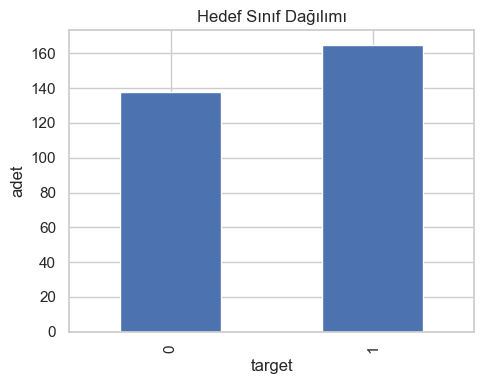

In [8]:
ax = target_counts.plot(kind="bar",figsize = (5,4))
ax.set_title("Hedef Sınıf Dağılımı")
ax.set_xlabel("target")
ax.set_ylabel("adet")
plt.tight_layout()
plt.show()

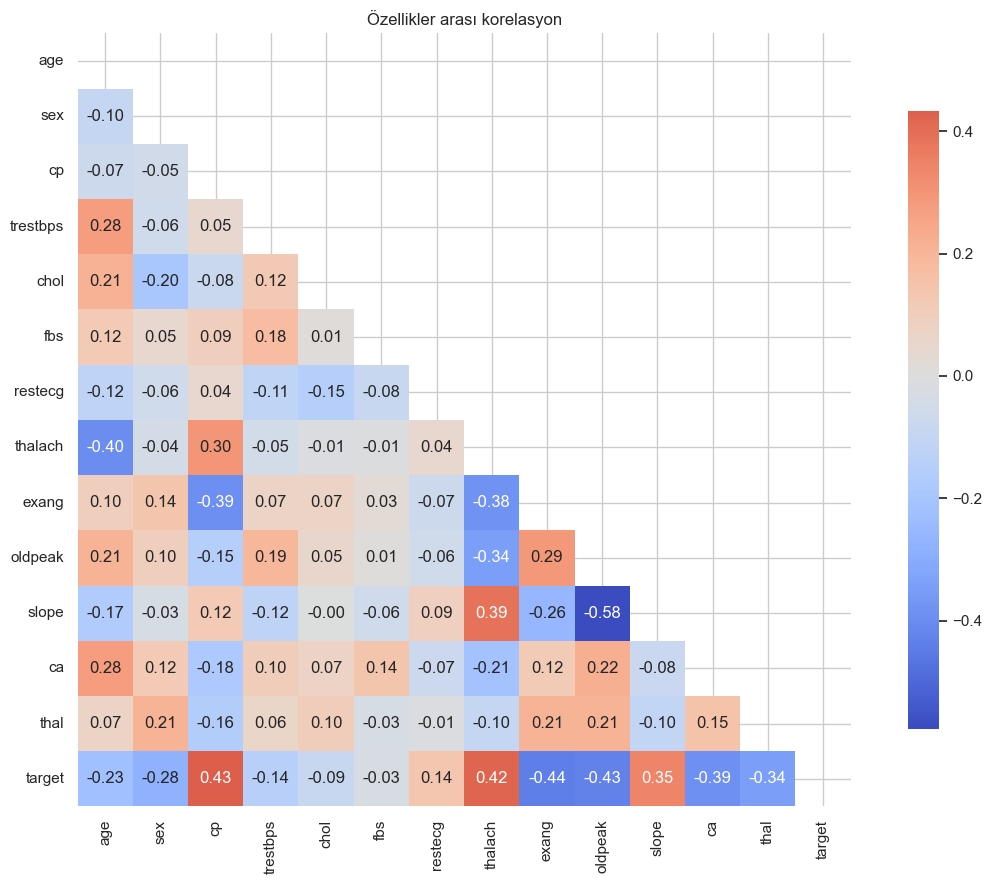

In [9]:
# Korelasyon ısı haritası
plt.figure(figsize=(12,9))

mask = np.triu(np.ones_like(df.corr(numeric_only=True), dtype=bool))
sns.heatmap(data=df.corr(numeric_only=True),annot=True,fmt=".2f",cmap="coolwarm",
            center=0,square=True,cbar_kws={"shrink": 0.8},
            mask= mask
)
plt.title("Özellikler arası korelasyon")
plt.tight_layout()
plt.show()

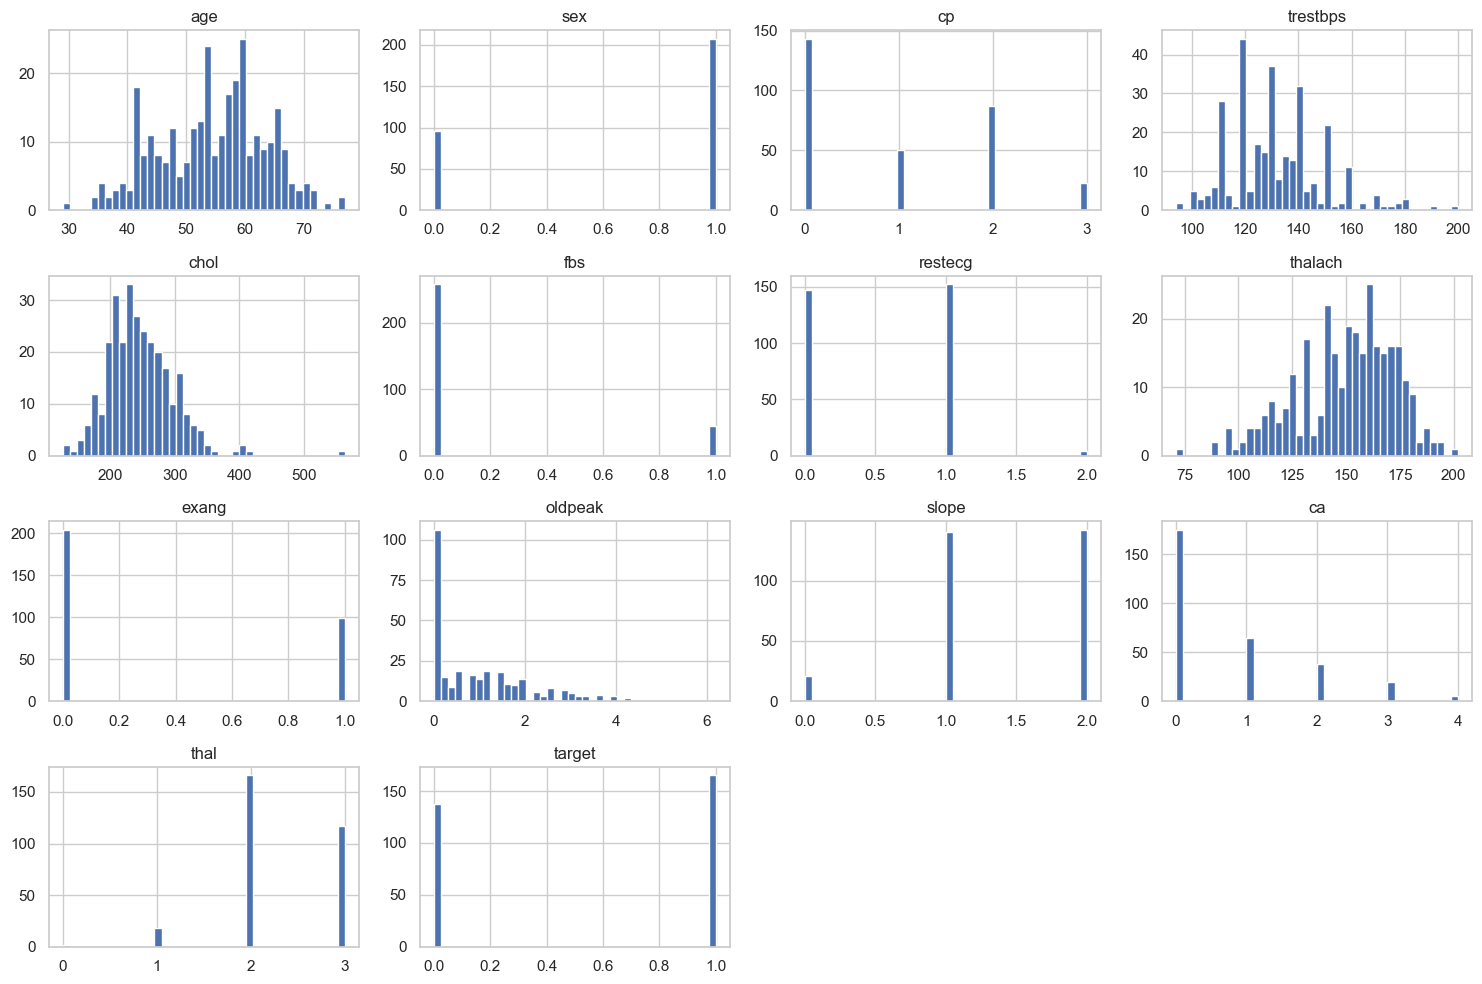

In [10]:
# Özelliklerin dağılımları
df.hist(bins = 40 , figsize =(15,10))
plt.tight_layout()
plt.show()

## 3. Eğitim / test ayrımı (stratified)

1. `stratify=y` — test setinin sınıf dağılımı eğitim setiyle aynı kalır.
2. `random_state` — ayrım tekrar üretilebilir olur.

Özellik seçimi ve model eğitimi **yalnızca eğitim seti** üzerinde yapılır;
böylece test setinden bilgi sızıntısı (data leakage) önlenir.

In [11]:
X = df.drop("target",axis = 1)
y = df["target"]

In [12]:
X_train , X_test , y_train, y_test = train_test_split(X,y , test_size=0.2 , random_state= RANDOM_STATE, stratify=y)
print(f"Eğitim: {X_train.shape}, Test: {X_test.shape}")

Eğitim: (242, 13), Test: (61, 13)


## 4. Çoklu doğrusallık (multicollinearity) kontrolü

Burada korelasyon matrisinin üst üçgenini vektörize bir şekilde tarayan temiz
bir yapı kullanıyor ve sonucu **hem eğitim hem test setine** uyguluyoruz.

> Not: Bu veri setinde 0.85 eşiğini aşan bir çift büyük olasılıkla yok, bu
> nedenle adım çoğunlukla hiçbir sütun düşürmez — ama metodolojik bütünlük
> için bulunur ve doğru şekilde uygulanır.

In [13]:
def get_correlated_features(frame, threshold=0.85):
    """Eşik değeri aşan korelasyona sahip sütunların listesini döndürür."""
    corr = frame.corr(numeric_only=True).abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    return [col for col in upper.columns if (upper[col] > threshold).any()]


correlated = get_correlated_features(X_train, threshold=0.85)
print("Düşürülecek yüksek korelasyonlu sütunlar:", correlated or "(yok)")

Düşürülecek yüksek korelasyonlu sütunlar: (yok)


In [14]:
# Eğitimde tespit edilen sütunlar her iki setten de düşürülür
X_train = X_train.drop(columns=correlated)
X_test = X_test.drop(columns=correlated)

## 5. Temel (baseline) model

Varsayılan hiperparametrelerle bir referans noktası oluşturuyoruz.
Optimizasyon sonrası bu skoru aşmayı bekliyoruz.

In [15]:
baseline = GradientBoostingClassifier(random_state=RANDOM_STATE)
baseline.fit(X_train , y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [16]:
y_pred_base = baseline.predict(X_test)

In [17]:
print("=== Baseline ===")
print(classification_report(y_test, y_pred_base))  
print(confusion_matrix(y_test, y_pred_base))

=== Baseline ===
              precision    recall  f1-score   support

           0       0.87      0.71      0.78        28
           1       0.79      0.91      0.85        33

    accuracy                           0.82        61
   macro avg       0.83      0.81      0.81        61
weighted avg       0.83      0.82      0.82        61

[[20  8]
 [ 3 30]]


## 6. Hiperparametre optimizasyonu (GridSearchCV)

İki iyileştirme:
- **`StratifiedKFold`** ile katmanlı çapraz doğrulama.
- **`scoring="roc_auc"`** — varsayılan accuracy yerine. Kalp hastalığı
  teşhisinde *false negative* (hastayı kaçırmak) maliyeti çok daha
  yüksektir; eşikten bağımsız ayırt etme gücünü ölçen ROC-AUC daha uygun
  bir optimizasyon hedefidir.

> `loss="exponential"` yalnızca ikili (binary) hedeflerde çalışır. Bu veri
> setinin hedefi ikili olduğu için sorun yoktur.

In [18]:
param_grid = {
    "loss" : ["log_loss","exponential"],
    "learning_rate" : [0.01 , 0.05 ,0.1],
    "n_estimators" : [100, 150, 180, 200],
    "max_depth" : [3,4,5],
    "subsample" : [0.8 , 1.0]
}

cv = StratifiedKFold(n_splits=5 , shuffle=True, random_state = RANDOM_STATE)

In [19]:
grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv = cv,
    scoring = "roc_auc",
    n_jobs=-1,
    verbose=1
)

In [20]:
grid_search.fit(X_train, y_train)          

Fitting 5 folds for each of 144 candidates, totalling 720 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'loss': ['log_loss', 'exponential'], 'max_depth': [3, 4, ...], 'n_estimators': [100, 150, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : 

In [21]:
print("En iyi parametreler:", grid_search.best_params_)
print(f"En iyi CV ROC-AUC: {grid_search.best_score_:.4f}")

En iyi parametreler: {'learning_rate': 0.01, 'loss': 'exponential', 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
En iyi CV ROC-AUC: 0.8758


## 7. Final değerlendirme

En iyi modeli, eğitim sırasında hiç görülmemiş test seti üzerinde değerlendiriyoruz. Accuracy'nin yanı sıra ROC-AUC, ROC eğrisi ve görsel confusion matrix ekliyoruz.

In [22]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

In [23]:
print("=== Optimize edilmiş model ===")
print(classification_report(y_test, y_pred))
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

=== Optimize edilmiş model ===
              precision    recall  f1-score   support

           0       0.95      0.64      0.77        28
           1       0.76      0.97      0.85        33

    accuracy                           0.82        61
   macro avg       0.85      0.81      0.81        61
weighted avg       0.85      0.82      0.81        61

Test ROC-AUC: 0.9069


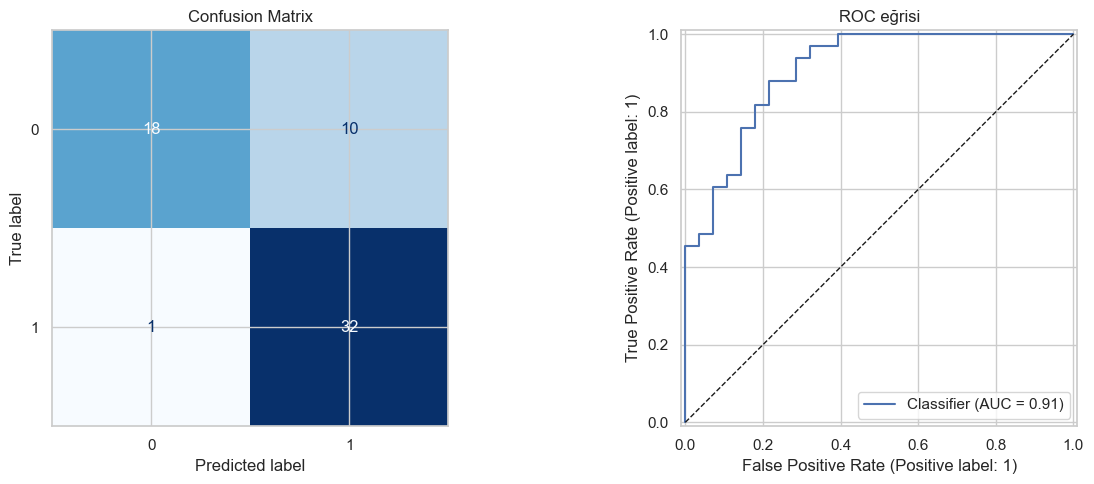

In [24]:
fig , axes = plt.subplots(1,2,figsize=(13,5))

ConfusionMatrixDisplay.from_predictions(y_test , y_pred ,ax= axes[0],cmap="Blues",colorbar=False)

axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[1].set_title("ROC eğrisi")

plt.tight_layout()
plt.show()

## 8. Özellik önemleri

Gradient Boosting modelinin hangi özelliklere ağırlık verdiğini görmek,hem model davranışını yorumlamak hem de klinik makullüğü
kontrol etmek için değerlidir.

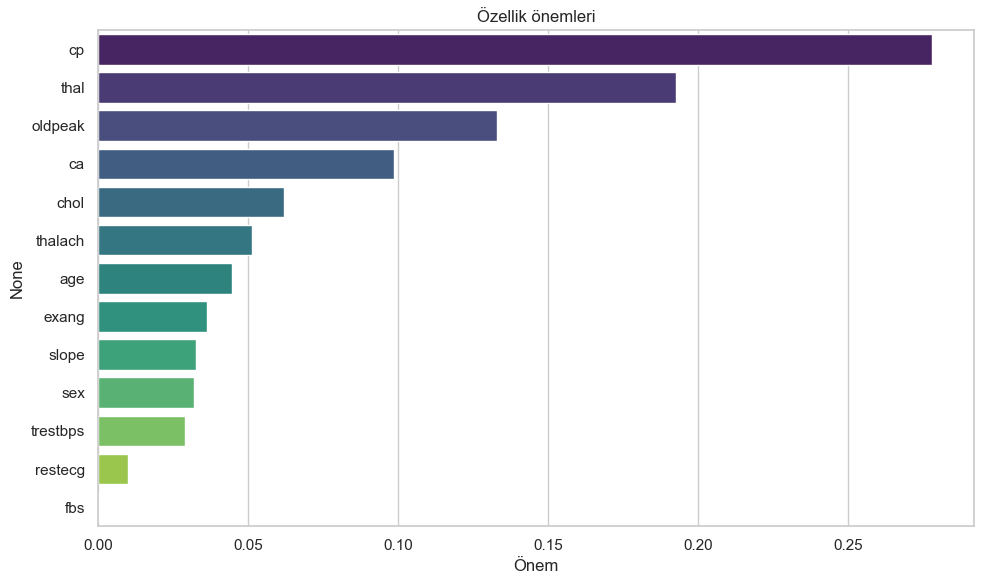

In [25]:
importances = (
    pd.Series(best_model.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Özellik önemleri")
plt.xlabel("Önem")
plt.tight_layout()
plt.show()

In [26]:
importances

cp          0.278108
thal        0.192727
oldpeak     0.133080
ca          0.098481
chol        0.061844
thalach     0.051405
age         0.044559
exang       0.036416
slope       0.032484
sex         0.031827
trestbps    0.029043
restecg     0.009810
fbs         0.000216
dtype: float64

## 9. Modeli kaydetme

Eğitilmiş modeli, tekrar üretilebilir bir teslimat için diske yazıyoruz.

In [27]:
joblib.dump(best_model, MODEL_PATH)
print(f"Model kaydedildi: {MODEL_PATH}")

# Geri yükleme örneği:
# loaded = joblib.load(MODEL_PATH)
# loaded.predict(X_test[:5])

Model kaydedildi: modeller\gradient_boosting_heart_.joblib


## 10. Sonuç

- Argüman sırası, tekrarlanabilirlik ve kullanılmayan özellik eleme adımı
  gibi sonuçları doğrudan etkileyen sorunlar giderildi.
- Optimizasyon hedefi, tıbbi bağlamın maliyet yapısına uygun olarak
  ROC-AUC'a çekildi.
- Çıktılar (metrikler, confusion matrix, ROC, özellik önemleri) bir
  rapora aktarılmaya hazır.

**Olası sonraki adımlar:** kalibrasyon eğrisi ve karar eşiği (threshold)
ayarı, `class_weight`/örnekleme ile dengesizlik yönetimi, özellik seçimi +
modeli tek bir `Pipeline` içinde toplayarak sızıntıya tam kapalı bir akış,
ve SHAP ile model açıklanabilirliği.